# Autoregressive Rollout Evaluation

Evaluates the trained conditional flow-matching model by rolling out predictions autoregressively:

$$\hat{x}_{t+1} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; x_t) \quad \rightarrow \quad \hat{x}_{t+2} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; \hat{x}_{t+1}) \quad \rightarrow \quad \cdots$$

**Metrics:**
- **RMSE** — Root Mean Squared Error of the ensemble mean vs. ground truth
- **CRPS** — Continuous Ranked Probability Score (probabilistic skill of marginal distributions)
- **SSR** — Spread/Skill Ratio (calibration: should be ~1 for a well-calibrated ensemble)

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted

# Import forecasting functions
from autoregressive_forecasting import (
    AutoregressiveConfig,
    load_model,
    autoregressive_ensemble_rollout,
    compute_rmse,
    compute_crps,
    compute_ssr,
    evaluate_autoregressive,
    print_metrics,
)

## 2. Config

In [7]:
# ── paths ─────────────────────────────────────────────────────────────────
MODEL_PATH = Path('../models/results/best_model_conditional.pth')

# ── data ──────────────────────────────────────────────────────────────────
DATA_STD   = 2660.0
TRAIN_FRAC = 0.8          # must match training split

# ── model (must match training config exactly) ────────────────────────────
IMG_CHANNELS   = 2
IMG_RESOLUTION = 64
FILTERS        = 32
LABEL_DROPOUT  = 0.1

# ── evaluation ────────────────────────────────────────────────────────────
N_ENSEMBLE    = 10    # number of ensemble members per rollout
ROLLOUT_STEPS = 5    # how many autoregressive steps to evaluate
ODE_STEPS     = 100   # Euler steps inside each ODE solve
N_INIT        = 20    # number of different starting points to average metrics over

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Model path exists: {MODEL_PATH.exists()}')

# Create config for autoregressive forecasting
config = AutoregressiveConfig(
    model_path=str(MODEL_PATH),
    data_std=DATA_STD,
    img_channels=IMG_CHANNELS,
    img_resolution=IMG_RESOLUTION,
    filters=FILTERS,
    label_dropout=LABEL_DROPOUT,
    n_ensemble=N_ENSEMBLE,
    ode_steps=ODE_STEPS,
    device=device,
)

Device: cuda
Model path exists: True


## 3. Load Data (val split only)

In [3]:
# load and split files by trajectory, not by time
hour = 3
DATA_DIR = Path('../data/') if hour ==1 else Path('../3hour_data/')
files = natsorted(DATA_DIR.glob(f'sqg_N64_{hour}hrly_*.npy'))
assert len(files) > 0, f"No files found in {DATA_DIR}"

cut        = int(len(files) * TRAIN_FRAC)
val_files  = files[cut:]
# should we use SQGPairDataset? it's for pair tho

# load all val trajectories
val_trajs = []
for f in val_files:
    arr = torch.tensor(np.load(f).astype(np.float32) / DATA_STD)  # (T, C, H, W)
    val_trajs.append(arr)

T_per_traj = val_trajs[0].shape[0]
print(f'Total trajectories: {len(files)},  train: {cut},  val: {len(val_files)}')
print(f'Timesteps per trajectory: {T_per_traj},  val data shape: {val_trajs[0].shape}')

# pick N_INIT (traj_idx, t) starting points from val trajectories
# ensure t + ROLLOUT_STEPS < T so we have enough ground truth
max_t      = T_per_traj - ROLLOUT_STEPS - 1
assert max_t > 0, 'Trajectory too short for requested rollout length'

rng          = np.random.default_rng(42)
traj_indices = rng.integers(0, len(val_trajs), size=N_INIT)
time_indices = rng.integers(0, max_t,          size=N_INIT)
init_points  = list(zip(traj_indices.tolist(), time_indices.tolist()))

print(f'\nSampled {N_INIT} init points: (traj_idx, t_start)')
for ti, t in init_points:
    print(f'  traj={ti}, t={t}')

Total trajectories: 100,  train: 80,  val: 20
Timesteps per trajectory: 101,  val data shape: torch.Size([101, 2, 64, 64])

Sampled 20 init points: (traj_idx, t_start)
  traj=1, t=40
  traj=15, t=29
  traj=13, t=14
  traj=8, t=74
  traj=8, t=62
  traj=17, t=51
  traj=1, t=32
  traj=13, t=65
  traj=4, t=43
  traj=1, t=35
  traj=10, t=36
  traj=19, t=18
  traj=14, t=7
  traj=15, t=44
  traj=14, t=71
  traj=15, t=5
  traj=10, t=68
  traj=2, t=66
  traj=16, t=22
  traj=9, t=50


## 4. Load Model

In [4]:
model = load_model(config)
print('Model loaded successfully via autoregressive_forecasting module')

Model loaded successfully via autoregressive_forecasting module


/home/trace/Documents/Projects/Thesis/Condition_model/autoregressive_forecasting.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(config

## 5. Sampling Function

In [5]:
# These functions are now imported from autoregressive_forecasting module:
# - sample_one_step()
# - autoregressive_ensemble_rollout()
# 
# No need to redefine them here. Use directly as imported above.

## 6. Metric Definitions

All metrics are computed **per lead time**, averaged over spatial pixels, channels, and init points.

- **RMSE**: $\sqrt{\mathbb{E}[(\bar{x}_{\text{pred}} - x_{\text{truth}})^2]}$ where $\bar{x}_{\text{pred}}$ is the ensemble mean
- **CRPS**: $\mathbb{E}_{m}[|x^m - x_{\text{truth}}|] - \frac{1}{2}\mathbb{E}_{m,m'}[|x^m - x^{m'}|]$ (energy form)
- **SSR**: $\frac{\text{ensemble spread}}{\text{RMSE}}$ — well-calibrated when $\approx 1$

In [6]:
# These metric functions are now imported from autoregressive_forecasting module:
# - compute_rmse()
# - compute_crps()
# - compute_ssr()
#
# No need to redefine them here. Use directly as imported above.

## 7. Run Evaluation

In [8]:
all_rmse = []
all_crps = []
all_ssr  = []

for ti, t in tqdm(init_points, desc='Evaluating init points'):
    x0    = val_trajs[ti][t]                                    # (C, H, W)
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()  # (steps, C, H, W)

    # ensemble rollout
    preds = autoregressive_ensemble_rollout(
        model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS
    )   # (steps, n_ens, C, H, W)

    preds_mean = preds.mean(axis=1)                                # (steps, C, H, W)

    rmse = compute_rmse(preds_mean, truth)                         # (steps,)
    crps = compute_crps(preds, truth)                              # (steps,)
    ssr  = compute_ssr(preds, rmse)                                # (steps,)

    all_rmse.append(rmse)
    all_crps.append(crps)
    all_ssr.append(ssr)

# average over init points
mean_rmse = np.stack(all_rmse).mean(axis=0)   # (steps,)
mean_crps = np.stack(all_crps).mean(axis=0)
mean_ssr  = np.stack(all_ssr).mean(axis=0)

lead_times = np.arange(1, ROLLOUT_STEPS + 1)

print(f'\nResults averaged over {N_INIT} init points:')
print(f'{"Lead":>5}  {"RMSE":>8}  {"CRPS":>8}  {"SSR":>8}')
for t, r, c, s in zip(lead_times, mean_rmse, mean_crps, mean_ssr):
    print(f'{t:5d}  {r:8.4f}  {c:8.4f}  {s:8.4f}')

Evaluating init points: 100%|██████████| 20/20 [08:33<00:00, 25.69s/it]


Results averaged over 20 init points:
 Lead      RMSE      CRPS       SSR
    1    0.3347    0.2305    0.0483
    2    0.5155    0.3631    0.0423
    3    0.6251    0.4456    0.0414
    4    0.7048    0.5066    0.0417
    5    0.7650    0.5537    0.0425


## 8. Plot Metrics vs Lead Time

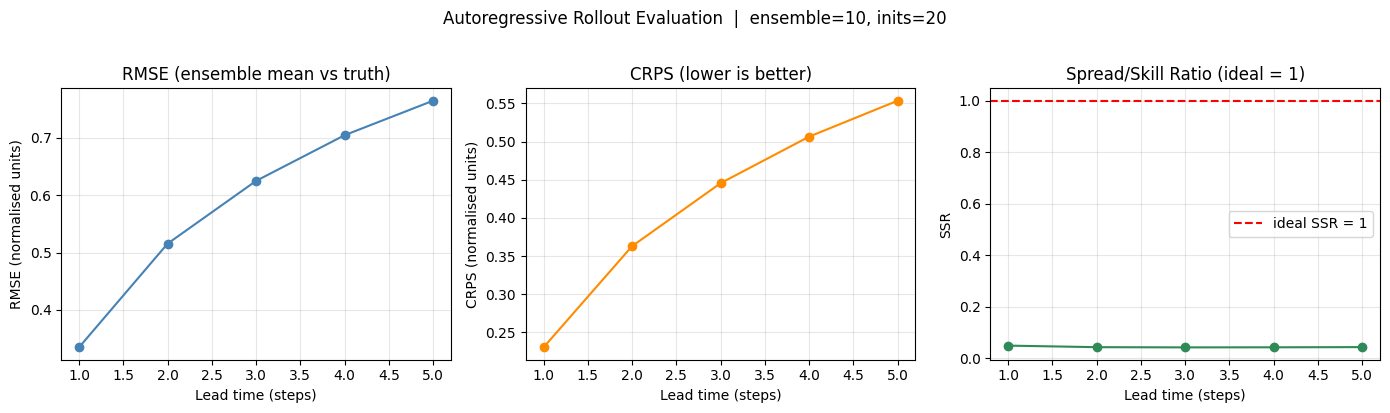

Plot saved to results/eval_metrics.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(lead_times, mean_rmse, marker='o', color='steelblue')
axes[0].set_title('RMSE (ensemble mean vs truth)')
axes[0].set_xlabel('Lead time (steps)')
axes[0].set_ylabel('RMSE (normalised units)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lead_times, mean_crps, marker='o', color='darkorange')
axes[1].set_title('CRPS (lower is better)')
axes[1].set_xlabel('Lead time (steps)')
axes[1].set_ylabel('CRPS (normalised units)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lead_times, mean_ssr, marker='o', color='seagreen')
axes[2].axhline(1.0, color='red', linestyle='--', label='ideal SSR = 1')
axes[2].set_title('Spread/Skill Ratio (ideal = 1)')
axes[2].set_xlabel('Lead time (steps)')
axes[2].set_ylabel('SSR')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Autoregressive Rollout Evaluation  |  ensemble={N_ENSEMBLE}, inits={N_INIT}', y=1.02)
plt.tight_layout()
plt.show()
print('Plot saved to results/eval_metrics.png')

## 9. Visual Sanity Check — One Rollout Trajectory

Plots the ground truth vs ensemble mean for a single init point at selected lead times.

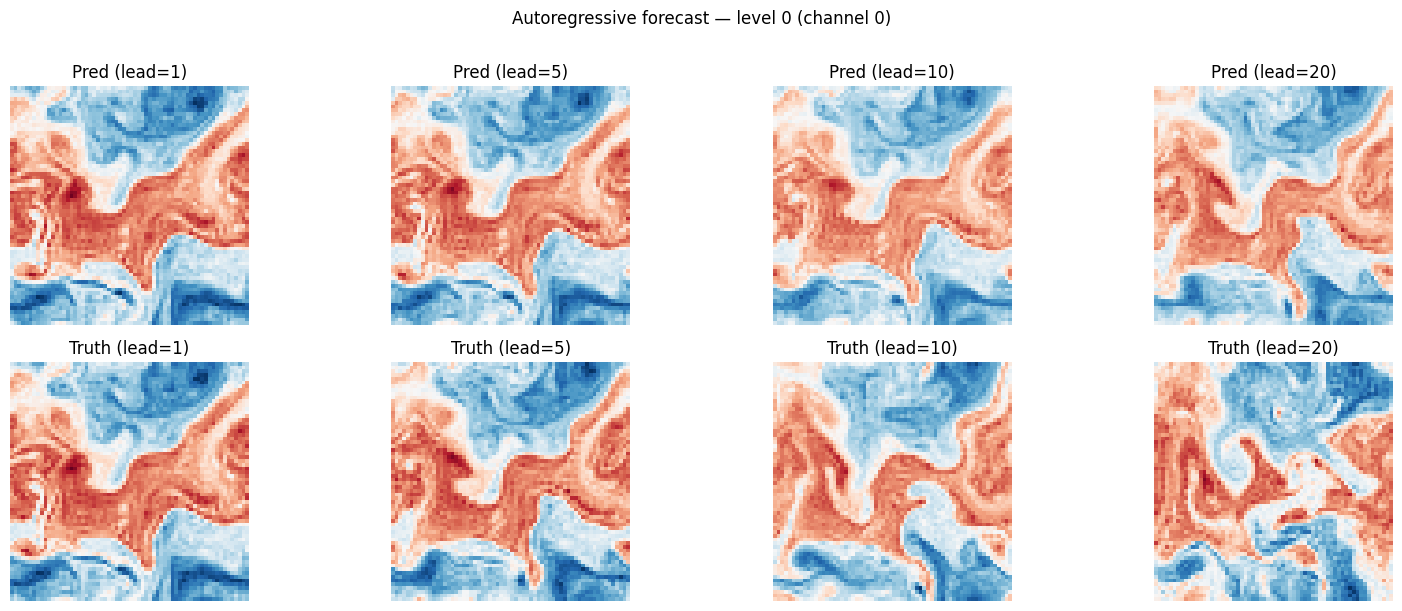

Trajectory plot saved to results/eval_trajectory.png


In [ ]:
# use the first init point
ti, t = init_points[0]
x0    = val_trajs[ti][t]
truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()


preds = autoregressive_ensemble_rollout(model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS)
preds_mean = preds.mean(axis=1)   # (steps, C, H, W)

# show steps 1, 5, 10, 20 (or fewer if ROLLOUT_STEPS < 20)
show_steps = [s for s in [1, 5, 10, 20] if s <= ROLLOUT_STEPS]
n_show = len(show_steps)

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
for col, step in enumerate(show_steps):
    vmax = np.abs(truth[step - 1, 0]).max()
    axes[0, col].imshow(preds_mean[step - 1, 0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, col].set_title(f'Pred (lead={step})')
    axes[0, col].axis('off')
    axes[1, col].imshow(truth[step - 1, 0],      cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1, col].set_title(f'Truth (lead={step})')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Ensemble Mean', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth',  fontsize=10)

plt.suptitle('Autoregressive forecast — level 0 (channel 0)', y=1.01)
plt.tight_layout()
plt.show()
print('Trajectory plot saved to results/eval_trajectory.png')

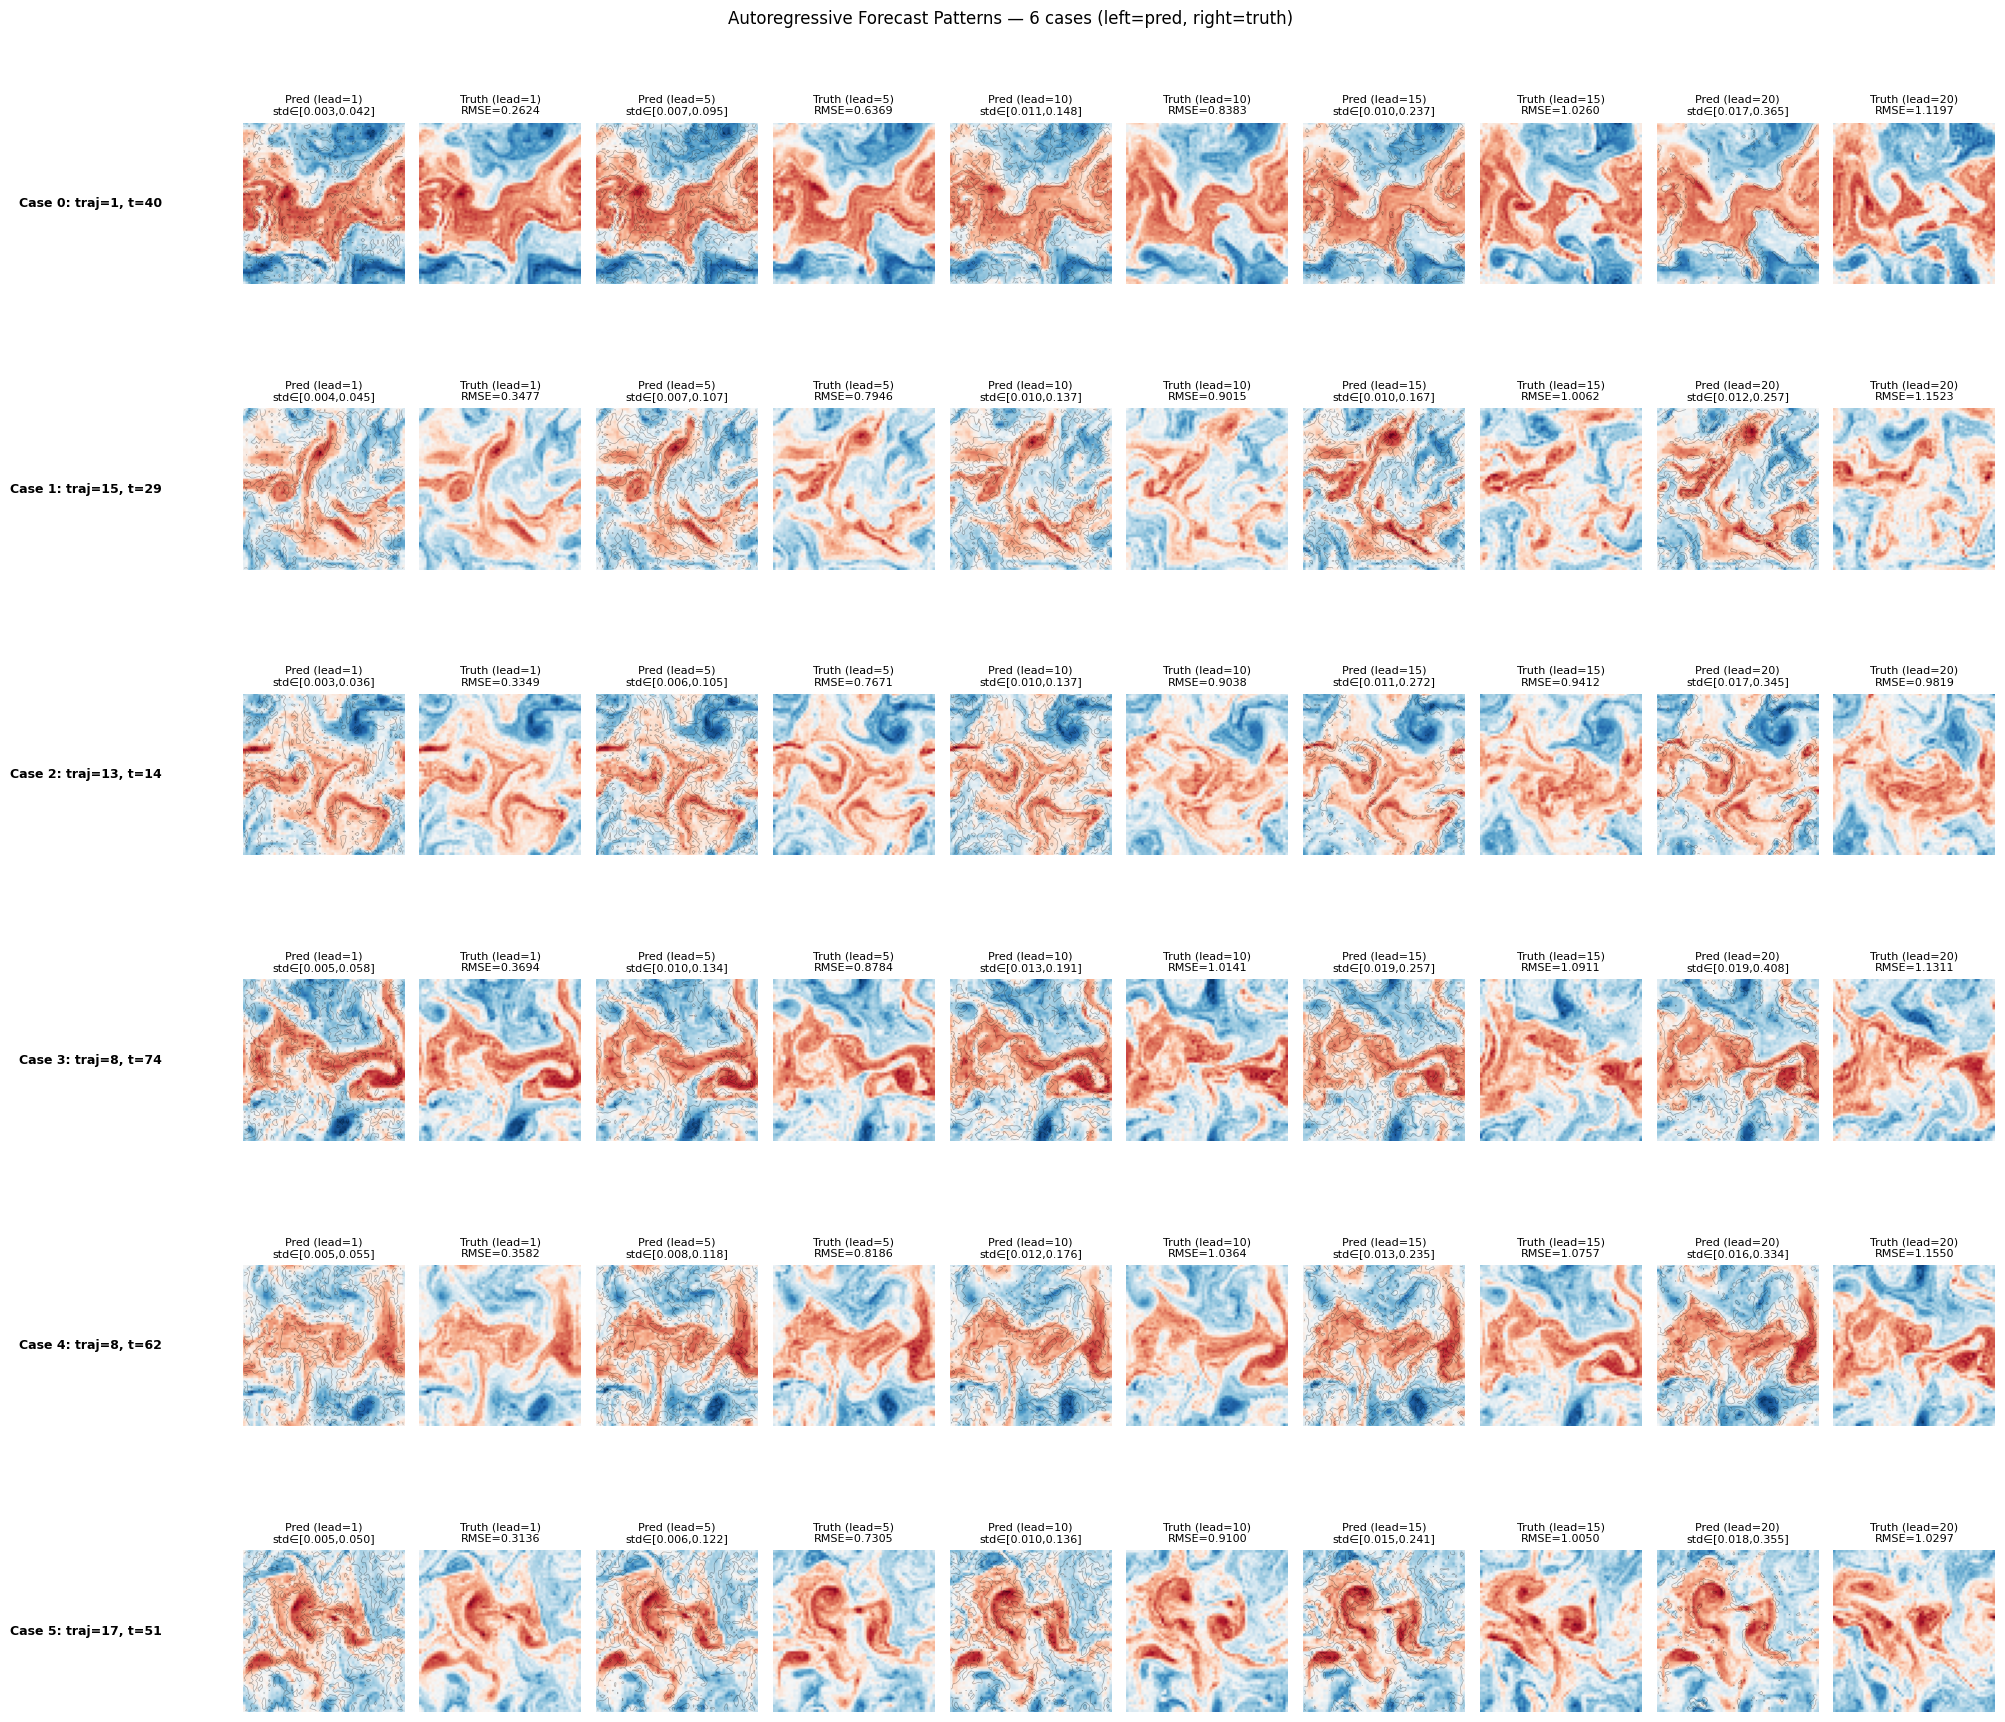


Case   Traj   t     L1      L5      L10     L15     L20     
----------------------------------------------------------
0      1      40    0.26/0.01  0.66/0.03  0.87/0.04  1.01/0.06  1.10/0.07  
1      15     29    0.34/0.02  0.80/0.03  0.92/0.05  1.05/0.06  1.15/0.08  
2      13     14    0.33/0.02  0.78/0.03  0.92/0.04  0.98/0.06  1.01/0.07  
3      8      74    0.37/0.02  0.86/0.04  0.97/0.06  1.04/0.07  1.09/0.09  
4      8      62    0.35/0.02  0.82/0.03  1.02/0.05  1.06/0.06  1.11/0.08  
5      17     51    0.31/0.02  0.73/0.03  0.89/0.04  0.99/0.06  1.04/0.07  

Format: RMSE/ensemble_spread for each lead time


In [14]:
# expand visualization: show multiple init points to examine forecasting patterns
n_cases = 6    # number of different init points to visualize
show_steps = [1, 5, 10, 15, 20]
show_steps = [s for s in show_steps if s <= ROLLOUT_STEPS]

fig, axes = plt.subplots(n_cases, len(show_steps) * 2, figsize=(4 * len(show_steps), 3 * n_cases))

for case_idx in range(n_cases):
    ti, t = init_points[case_idx]
    x0    = val_trajs[ti][t]
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()

    preds = autoregressive_ensemble_rollout(model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS)
    preds_mean = preds.mean(axis=1)   # (steps, C, H, W)
    preds_std = preds.std(axis=1)     # (steps, C, H, W)

    for col, step in enumerate(show_steps):
        step_idx = step - 1
        
        # use consistent colormap limits for comparison
        pred_val = preds_mean[step_idx, 0]
        truth_val = truth[step_idx, 0]
        vmax = max(np.abs(pred_val).max(), np.abs(truth_val).max())
        
        # show ensemble std as well
        std_val = preds_std[step_idx, 0]
        
        # Prediction with uncertainty
        ax_pred = axes[case_idx, col * 2]
        im = ax_pred.imshow(pred_val, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        # overlay std as contour
        cs = ax_pred.contour(std_val, levels=3, colors='black', alpha=0.3, linewidths=0.5)
        ax_pred.set_title(f'Pred (lead={step})\nstd∈[{std_val.min():.3f},{std_val.max():.3f}]', fontsize=8)
        ax_pred.axis('off')
        
        # Ground truth
        ax_truth = axes[case_idx, col * 2 + 1]
        ax_truth.imshow(truth_val, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        rmse_val = np.sqrt(((pred_val - truth_val) ** 2).mean())
        ax_truth.set_title(f'Truth (lead={step})\nRMSE={rmse_val:.4f}', fontsize=8)
        ax_truth.axis('off')

    # label cases on the left
    axes[case_idx, 0].text(-0.5, 0.5, f'Case {case_idx}: traj={ti}, t={t}', 
                           transform=axes[case_idx, 0].transAxes,
                           fontsize=9, ha='right', va='center', fontweight='bold')

plt.suptitle(f'Autoregressive Forecast Patterns — {n_cases} cases (left=pred, right=truth)', 
             fontsize=12, y=0.995)
plt.tight_layout()
plt.show()

# also print RMSE and spread for each case to quantify the pattern
print(f"\n{'Case':<6} {'Traj':<6} {'t':<6}", end='')
for step in show_steps:
    print(f"{'L' + str(step):<8}", end='')
print()
print("-" * (6 + 6 + 6 + 8 * len(show_steps)))

for case_idx in range(n_cases):
    ti, t = init_points[case_idx]
    x0    = val_trajs[ti][t]
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()

    preds = autoregressive_ensemble_rollout(model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS)
    preds_mean = preds.mean(axis=1)
    preds_std = preds.std(axis=1)
    
    print(f'{case_idx:<6} {ti:<6} {t:<6}', end='')
    for step in show_steps:
        step_idx = step - 1
        rmse = np.sqrt(((preds_mean[step_idx] - truth[step_idx]) ** 2).mean())
        spread = preds_std[step_idx].mean()
        print(f'{rmse:.2f}/{spread:.2f}', end='  ')
    print()

print("\nFormat: RMSE/ensemble_spread for each lead time")

## 10. Generate Forecast Animation GIFs

Creates side-by-side animated GIFs showing predicted vs ground truth trajectories for selected cases.

In [17]:
from matplotlib.animation import PillowWriter, FuncAnimation
from pathlib import Path

# Create results directory if it doesn't exist
results_dir = Path('../models/results')
results_dir.mkdir(parents=True, exist_ok=True)

n_gifs = 5  # number of GIF animations to create

print(f'Generating {n_gifs} forecast animation GIFs...\n')

for gif_idx in tqdm(range(n_gifs), desc='Creating GIFs'):
    ti, t = init_points[gif_idx]
    x0 = val_trajs[ti][t]
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()  # (steps, C, H, W)
    
    preds = autoregressive_ensemble_rollout(model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS)
    preds_mean = preds.mean(axis=1)   # (steps, C, H, W)
    preds_std = preds.std(axis=1)     # (steps, C, H, W)
    
    # Create figure with side-by-side frames
    fig, (ax_pred, ax_truth) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'Forecast Animation {gif_idx+1}: traj={ti}, t={t} (Channel 0)', fontsize=12)
    
    # Find global vmin/vmax across all timesteps for consistent coloring
    vmax = max(np.abs(preds_mean[:, 0]).max(), np.abs(truth[:, 0]).max())
    
    # Initialize images
    im_pred = ax_pred.imshow(preds_mean[0, 0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_pred.set_title('Predicted')
    ax_pred.axis('off')
    
    im_truth = ax_truth.imshow(truth[0, 0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax_truth.set_title('Ground Truth')
    ax_truth.axis('off')
    
    # Text annotations
    text_pred = ax_pred.text(0.5, -0.1, '', transform=ax_pred.transAxes, ha='center', fontsize=10)
    text_truth = ax_truth.text(0.5, -0.1, '', transform=ax_truth.transAxes, ha='center', fontsize=10)
    
    plt.colorbar(im_pred, ax=ax_pred, label='Value')
    plt.colorbar(im_truth, ax=ax_truth, label='Value')
    plt.tight_layout()
    
    # Animation frames
    def animate(frame):
        im_pred.set_array(preds_mean[frame, 0])
        im_truth.set_array(truth[frame, 0])
        
        rmse = np.sqrt(((preds_mean[frame] - truth[frame]) ** 2).mean())
        spread = preds_std[frame].mean()
        
        text_pred.set_text(f'Step {frame+1}/{ROLLOUT_STEPS}\nSpread: {spread:.4f}')
        text_truth.set_text(f'Step {frame+1}/{ROLLOUT_STEPS}\nRMSE: {rmse:.4f}')
        
        return im_pred, im_truth, text_pred, text_truth
    
    # Save as GIF
    writer = PillowWriter(fps=2)
    gif_path = results_dir / f'forecast_case{gif_idx:02d}_traj{ti}_t{t}.gif'
    
    anim = FuncAnimation(fig, animate, frames=ROLLOUT_STEPS, 
                         interval=500, blit=True, repeat=True)
    anim.save(gif_path, writer=writer)
    plt.close(fig)
    
    print(f'  ✓ Saved {gif_path.name}')

print(f'\n✓ All GIFs saved to: {results_dir}')
print(f'Files: forecast_case*.gif')

Generating 5 forecast animation GIFs...



Creating GIFs:  20%|██        | 1/5 [01:45<07:00, 105.04s/it]

  ✓ Saved forecast_case00_traj1_t40.gif


Creating GIFs:  40%|████      | 2/5 [03:30<05:15, 105.24s/it]

  ✓ Saved forecast_case01_traj15_t29.gif


...

  ✓ Saved forecast_case02_traj13_t14.gif


Creating GIFs:  80%|████████  | 4/5 [07:02<01:45, 105.68s/it]

  ✓ Saved forecast_case03_traj8_t74.gif


Creating GIFs: 100%|██████████| 5/5 [08:48<00:00, 105.61s/it]

  ✓ Saved forecast_case04_traj8_t62.gif

✓ All GIFs saved to: ../models/results
Files: forecast_case*.gif
